#Business context
The hospitality industry runs on thin margins. For hotel managers, every empty room is lost revenue that can never be recovered — unlike, say, unsold inventory in retail. One of the biggest threats to occupancy rates isn't poor marketing or bad reviews. It's cancellations.
Over the past decade, the rise of OTAs (Online Travel Agencies) like Booking.com and Expedia has made it incredibly easy for guests to reserve a room with zero commitment — and cancel just as easily. Hotels are left scrambling: they've blocked the room, turned away other guests, and now sit with nothing to show for it.
This dataset captures real booking records from two hotels in Portugal — a city hotel in Lisbon and a resort hotel in the Algarve — covering arrivals between July 2015 and August 2017. It logs everything from how far in advance guests booked, where they came from, what room they requested, how many times they changed their reservation, and — critically — whether they cancelled.
#Problem Statement
Despite having a reservation system in place, both hotels suffer from high cancellation rates that erode revenue predictability and make resource planning — from staffing to room allocation — unnecessarily difficult.
The goal of this analysis is to understand why cancellations happen and who is most likely to cancel. By digging into booking patterns, guest behavior, lead times, and market segments, we aim to surface the hidden signals that precede a cancellation — signals that a hotel's revenue manager could act on in real time.


In [1]:
#Import the libraries

#Data manipulation
import numpy as np
import pandas as pd

#Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Ignore warning messages
import warnings
warnings.filterwarnings('ignore')

#display all the columns
pd.set_option('display.max_columns', None)

#Make plot looks cleaner
sns.set_style('whitegrid')

#Prevents tiny graphs
plt.rcParams['figure.figsize'] = (10,6)

In [2]:
#Load the dataset
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/EDA-Hotel-Booking-Demand/hotel_bookings.csv')


Mounted at /content/drive


In [3]:
# gives the dimensions of the dataset (records , no_of_columns)
df.shape
# Gives the entire features and their data types along with count of non null entries
df.info()
# Gives the summary of the descriptive statistics of the dataset
df.describe()

df.info()
df.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,NaN,NaN,0,Transient,107.00,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,0.0,0,FB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,303.0,NaN,0,Transient,103.00,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,82.00,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,0.0,0,HB,PRT,Offline TA/TO,TA/TO,0,0,0,D,D,0,No Deposit,15.0,NaN,0,Transient,105.50,0,0,Canceled,2015-04-22


df.describe() -> It generates a summary of descriptive statistics for your dataset. By default, it automatically filters out text columns and provides a quick statistical snapshot of every numeric column . This is very useful in finding the outliers, skewness, strange values in each columns . These are the potential red flags and patterns that should be looked into for more gaining more meaningful insights and correlation

In [4]:
#finding the missing values
df.isnull().sum()

#df.duplicated().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [5]:
#missing agents means, those are the direct bookings
df['agent'].fillna(0, inplace=True)
#since 94.30% of the entires are null, it is better to drop them.
df.drop(columns='company', inplace=True)
#some entries doesnt have country name, which is of percentage 25.16%
df['country'].fillna('Unknown', inplace=True)
# since 0.003% of the entires in the children field is present with null values , it is safe to drop them
df.dropna(subset=['children'], inplace=True)

In [6]:
#tells about how many rows are duplicated entirely (i.e all the features)
df.duplicated().sum()
# tells what feature is repeated in each feature
df[df.duplicated()].iloc[0]

,5
hotel,Resort Hotel
is_canceled,0
lead_time,14
arrival_date_year,2015
arrival_date_month,July
arrival_date_week_number,27
arrival_date_day_of_month,1
stays_in_weekend_nights,0
stays_in_week_nights,2
adults,2


Although duplicate records were detected,
the dataset does not contain a unique booking identifier.
Many repeated rows may represent legitimate
independent bookings with similar attributes.
Therefore, duplicate removal was not performed
aggressively to avoid accidental information loss.

In [7]:
#data type inspection and correction
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])
#children count is discrete integer so they are converted to int from float
df['children'] = df['children'].astype('int64')

df['agent'] = df['agent'].astype('int64')

month_mapping = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df['arrival_date_month'] = df['arrival_date_month'].map(month_mapping).astype('int64')

#Since they have repeated names of limited types so labelled them as category type
category_cols = [
    'hotel', 'meal', 'market_segment', 'deposit_type', 'customer_type',
    'distribution_channel',
    'reserved_room_type',
    'assigned_room_type',
    'is_repeated_guest',
    'arrival_date_year'
]

for col in category_cols:
    df[col] = df[col].astype('category')

In [8]:
df[(df['adults'] == 0) &
   (df['children'] == 0) &
   (df['babies'] == 0)]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2224,Resort Hotel,0,1,2015,10,41,6,0,3,0,0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,1,No Deposit,0,0,Transient-Party,0.00,0,0,Check-Out,2015-10-06
2409,Resort Hotel,0,0,2015,10,42,12,0,0,0,0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,0,No Deposit,0,0,Transient,0.00,0,0,Check-Out,2015-10-12
3181,Resort Hotel,0,36,2015,11,47,20,1,2,0,0,0,SC,ESP,Groups,TA/TO,0,0,0,A,C,0,No Deposit,38,0,Transient-Party,0.00,0,0,Check-Out,2015-11-23
3684,Resort Hotel,0,165,2015,12,53,30,1,4,0,0,0,SC,PRT,Groups,TA/TO,0,0,0,A,A,1,No Deposit,308,122,Transient-Party,0.00,0,0,Check-Out,2016-01-04
3708,Resort Hotel,0,165,2015,12,53,30,2,4,0,0,0,SC,PRT,Groups,TA/TO,0,0,0,A,C,1,No Deposit,308,122,Transient-Party,0.00,0,0,Check-Out,2016-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115029,City Hotel,0,107,2017,6,26,27,0,3,0,0,0,BB,CHE,Online TA,TA/TO,0,0,0,A,A,1,No Deposit,7,0,Transient,100.80,0,0,Check-Out,2017-06-30
115091,City Hotel,0,1,2017,6,26,30,0,1,0,0,0,SC,PRT,Complementary,Direct,0,0,0,E,K,0,No Deposit,0,0,Transient,0.00,1,1,Check-Out,2017-07-01
116251,City Hotel,0,44,2017,7,28,15,1,1,0,0,0,SC,SWE,Online TA,TA/TO,0,0,0,A,K,2,No Deposit,425,0,Transient,73.80,0,0,Check-Out,2017-07-17
116534,City Hotel,0,2,2017,7,28,15,2,5,0,0,0,SC,RUS,Online TA,TA/TO,0,0,0,A,K,1,No Deposit,9,0,Transient-Party,22.86,0,1,Check-Out,2017-07-22


In [9]:
# these shows the logical flaws like booking is made with zero persons since they leads to false assumptioins. remove them
df[(df['adults'] == 0) &
   (df['children'] == 0) &
   (df['babies'] == 0)].shape

df = df[~((df['adults'] == 0) &
          (df['children'] == 0) &
          (df['babies'] == 0))]

**Univariant analysis:**

In this analysis, we will be finding out the outliers and the skewness exist in the features.

In [10]:
# this is for identifing the numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = [col for col in numerical_cols if col not in ['is_canceled', 'agent']]
# this is for the skewness score analysis of each numerical cols
skewness = df[numerical_cols].skew().sort_values(ascending=False)
skewness

,0
babies,24.627549
previous_cancellations,24.443516
previous_bookings_not_canceled,23.539161
adults,18.774993
days_in_waiting_list,11.948665
adr,10.613794
booking_changes,5.499965
required_car_parking_spaces,4.162264
children,4.108967
stays_in_week_nights,2.754929


In [11]:
def outlier_count_zscore(column):
    # Ensure the column has variation to avoid division by zero
    mean = column.mean()
    std = column.std()

    if std == 0:
        return 0

    # Calculate Z-scores
    z_scores = (column - mean) / std

    # Count values outside [-3, 3] range
    return ((z_scores < -3) | (z_scores > 3)).sum()

In [12]:
# finding the outliers present in the numerical cols
outlier_summary = {}

for col in numerical_cols:
    outlier_summary[col] = outlier_count_zscore(df[col])

In [13]:
# better presentation of the outliers count
outlier_df = pd.DataFrame(
    outlier_summary.items(),
    columns=['Feature', 'Outlier_Count']
)

outlier_df.sort_values(by='Outlier_Count', ascending=False)

,Feature,Outlier_Count
14,required_car_parking_spaces,7409
7,children,3729
15,total_of_special_requests,2874
4,stays_in_weekend_nights,2182
12,days_in_waiting_list,1867
5,stays_in_week_nights,1652
11,booking_changes,1532
0,lead_time,1453
13,adr,1140
10,previous_bookings_not_canceled,933


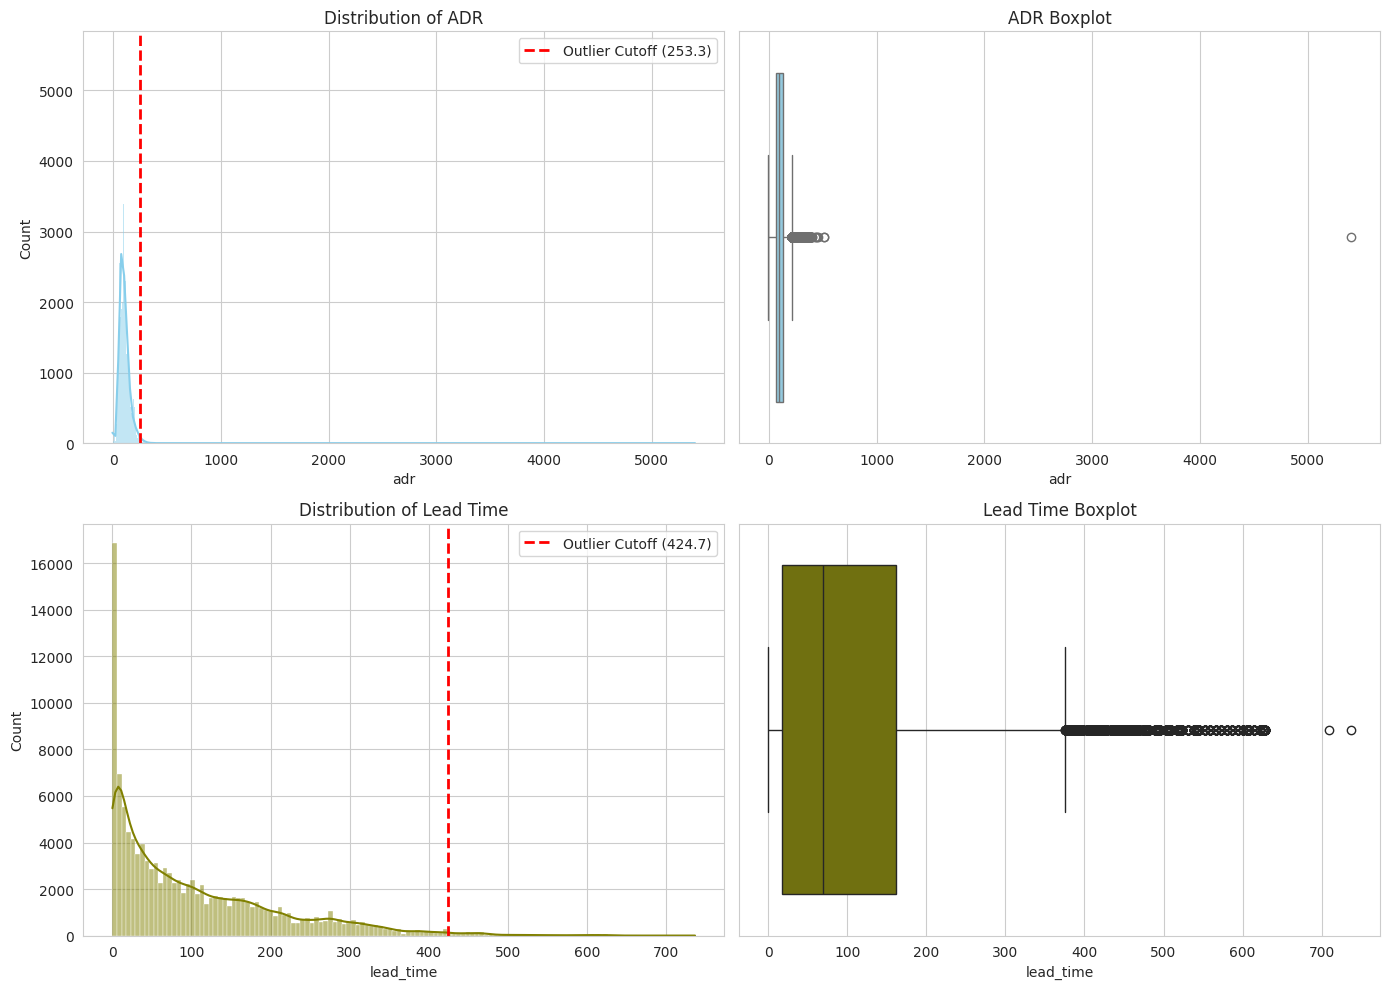

In [14]:
# visualization of the numerical cols
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Top-Left: ADR Histogram with Z-score Cutoff Line
sns.histplot(df["adr"], kde=True, ax=axes[0, 0], color="skyblue")
cutoff_adr = df["adr"].mean() + 3 * df["adr"].std()
axes[0, 0].axvline(cutoff_adr, color="red", linestyle="--", linewidth=2, label=f"Outlier Cutoff ({cutoff_adr:.1f})")
axes[0, 0].set_title("Distribution of ADR")
axes[0, 0].legend()

# 2. Top-Right: ADR Boxplot
sns.boxplot(x=df["adr"], ax=axes[0, 1], color="skyblue")
axes[0, 1].set_title("ADR Boxplot")

# 3. Bottom-Left: Lead Time Histogram with Z-score Cutoff Line
sns.histplot(df["lead_time"], kde=True, ax=axes[1, 0], color="olive")
cutoff_lead = df["lead_time"].mean() + 3 * df["lead_time"].std()
axes[1, 0].axvline(cutoff_lead, color="red", linestyle="--", linewidth=2, label=f"Outlier Cutoff ({cutoff_lead:.1f})")
axes[1, 0].set_title("Distribution of Lead Time")
axes[1, 0].legend()

# 4. Bottom-Right: Lead Time Boxplot
sns.boxplot(x=df["lead_time"], ax=axes[1, 1], color="olive")
axes[1, 1].set_title("Lead Time Boxplot")

plt.tight_layout()
plt.show()


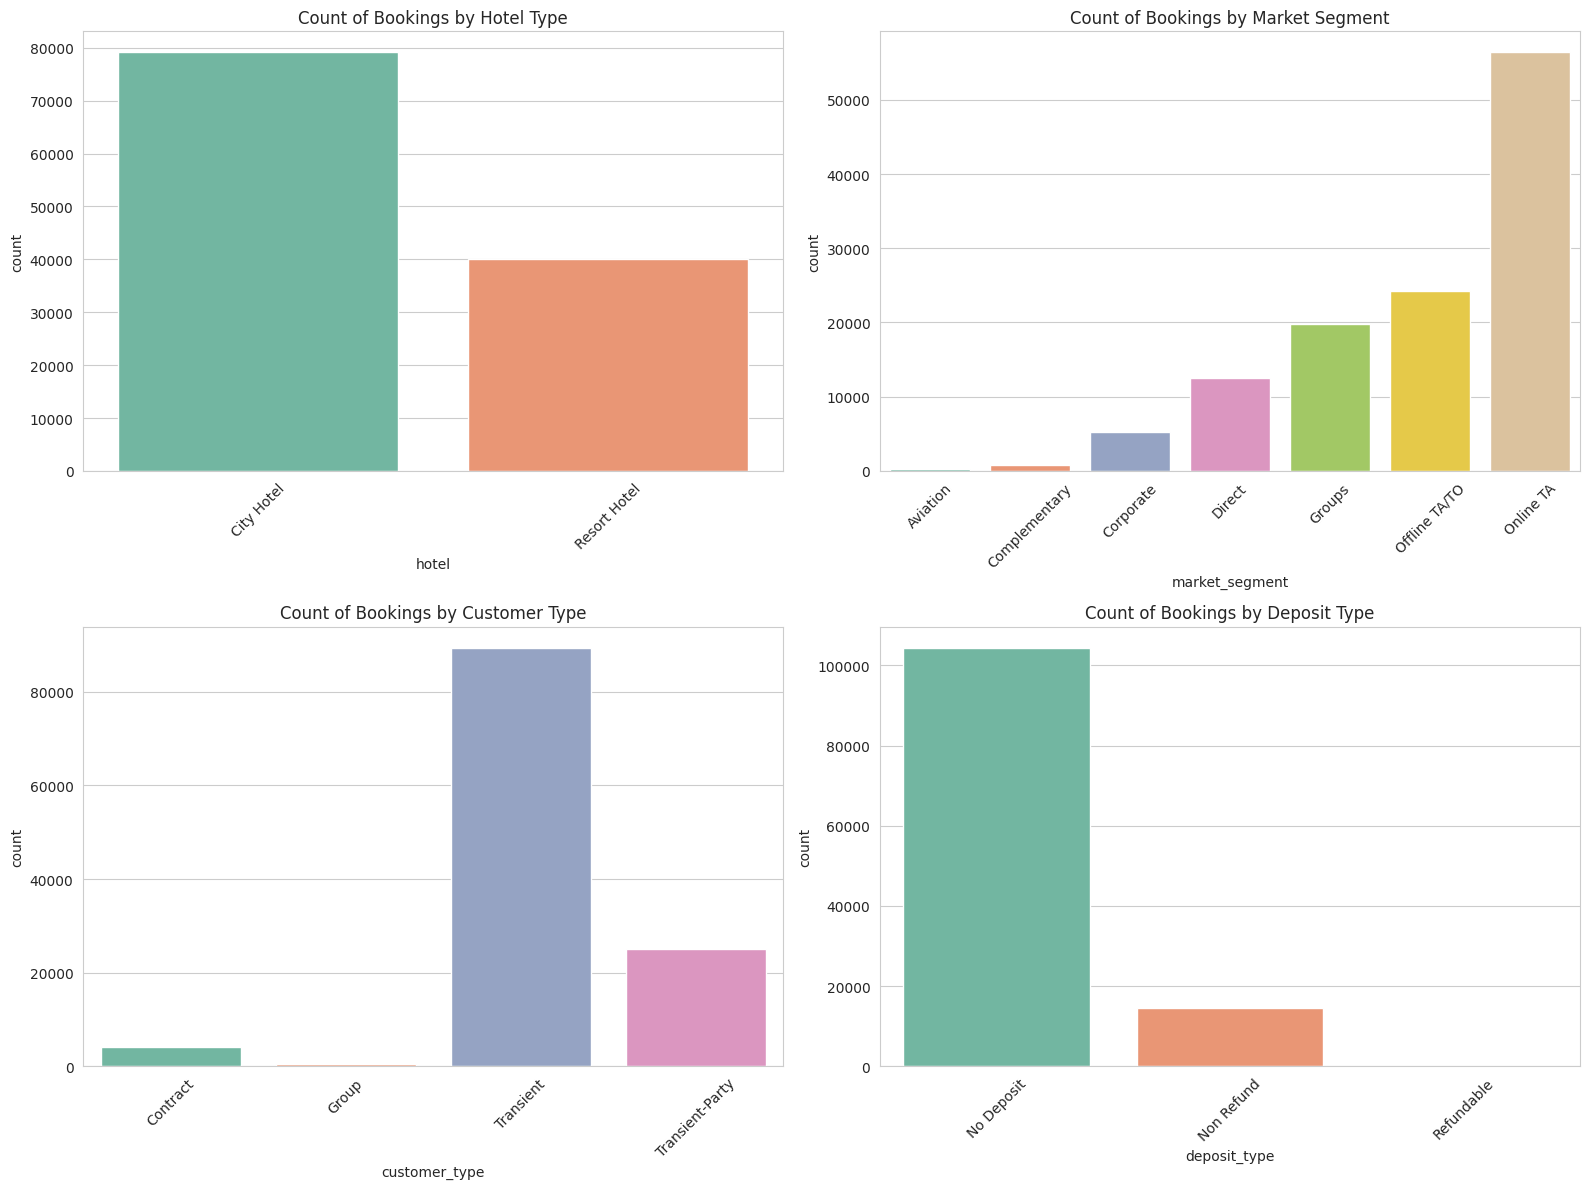

In [15]:
# visualization of the categorical cols
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top-Left: Hotel
sns.countplot(data=df, x="hotel", ax=axes[0, 0], hue="hotel", palette="Set2", legend=False)
axes[0, 0].set_title("Count of Bookings by Hotel Type")
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Top-Right: Market Segment
sns.countplot(data=df, x="market_segment", ax=axes[0, 1], hue="market_segment", palette="Set2", legend=False)
axes[0, 1].set_title("Count of Bookings by Market Segment")
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Bottom-Left: Customer Type
sns.countplot(data=df, x="customer_type", ax=axes[1, 0], hue="customer_type", palette="Set2", legend=False)
axes[1, 0].set_title("Count of Bookings by Customer Type")
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Bottom-Right: Deposit Type
sns.countplot(data=df, x="deposit_type", ax=axes[1, 1], hue="deposit_type", palette="Set2", legend=False)
axes[1, 1].set_title("Count of Bookings by Deposit Type")
axes[1, 1].tick_params(axis='x', rotation=45)

# Fix spacing so labels and titles do not overlap
plt.tight_layout()
plt.show()


**Context:** The dataset exhibits naturally high positive skewness across key behavioral features (babies, previous_cancellations, booking_changes, days_in_waiting_list).

**Inference:** This skewness is completely logical. It reflects standard consumer habits, where the vast majority of transactions score zero or baseline values, while a tiny fraction of bookings generate a long right tail.

**The Failure of IQR:** The traditional IQR method failed for this dataset because zero-inflated, right-skewed distributions collapse the IQR box down to 0. This caused normal human variations (like a family booking for 3 adults) to be misclassified, resulting in massive false-positive counts (e.g., 29,529 false outliers for adults).

**The Success of Z-Score:** Switching to a Z-score threshold of
corrected this bias. It properly accommodated natural variations and successfully isolated genuine extreme observations (reducing adults outliers to just 301).


**Bivariate and multivariate analysis:**

In this analysis , we will be finding out the relationship between the varibles. This is where the insights emerges.Correlation matrix is one of the functionality that gives out relationship .


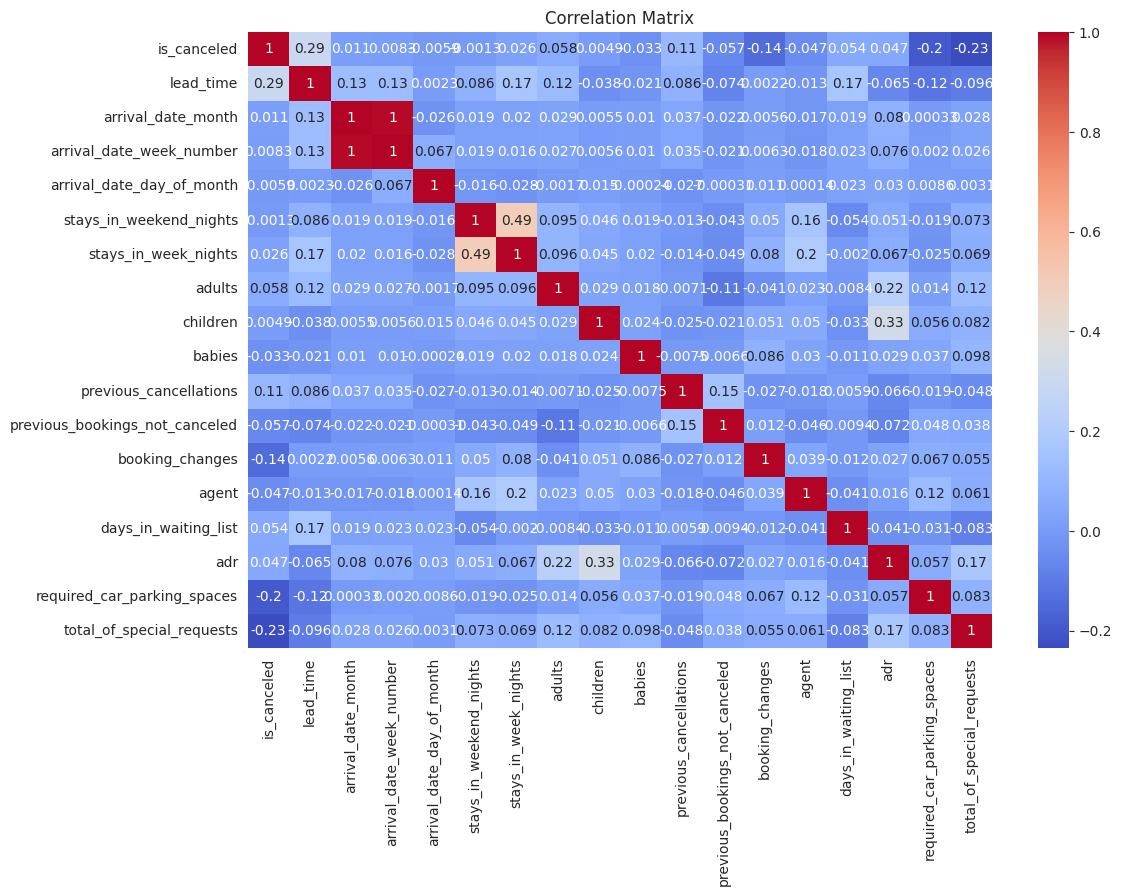

In [16]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

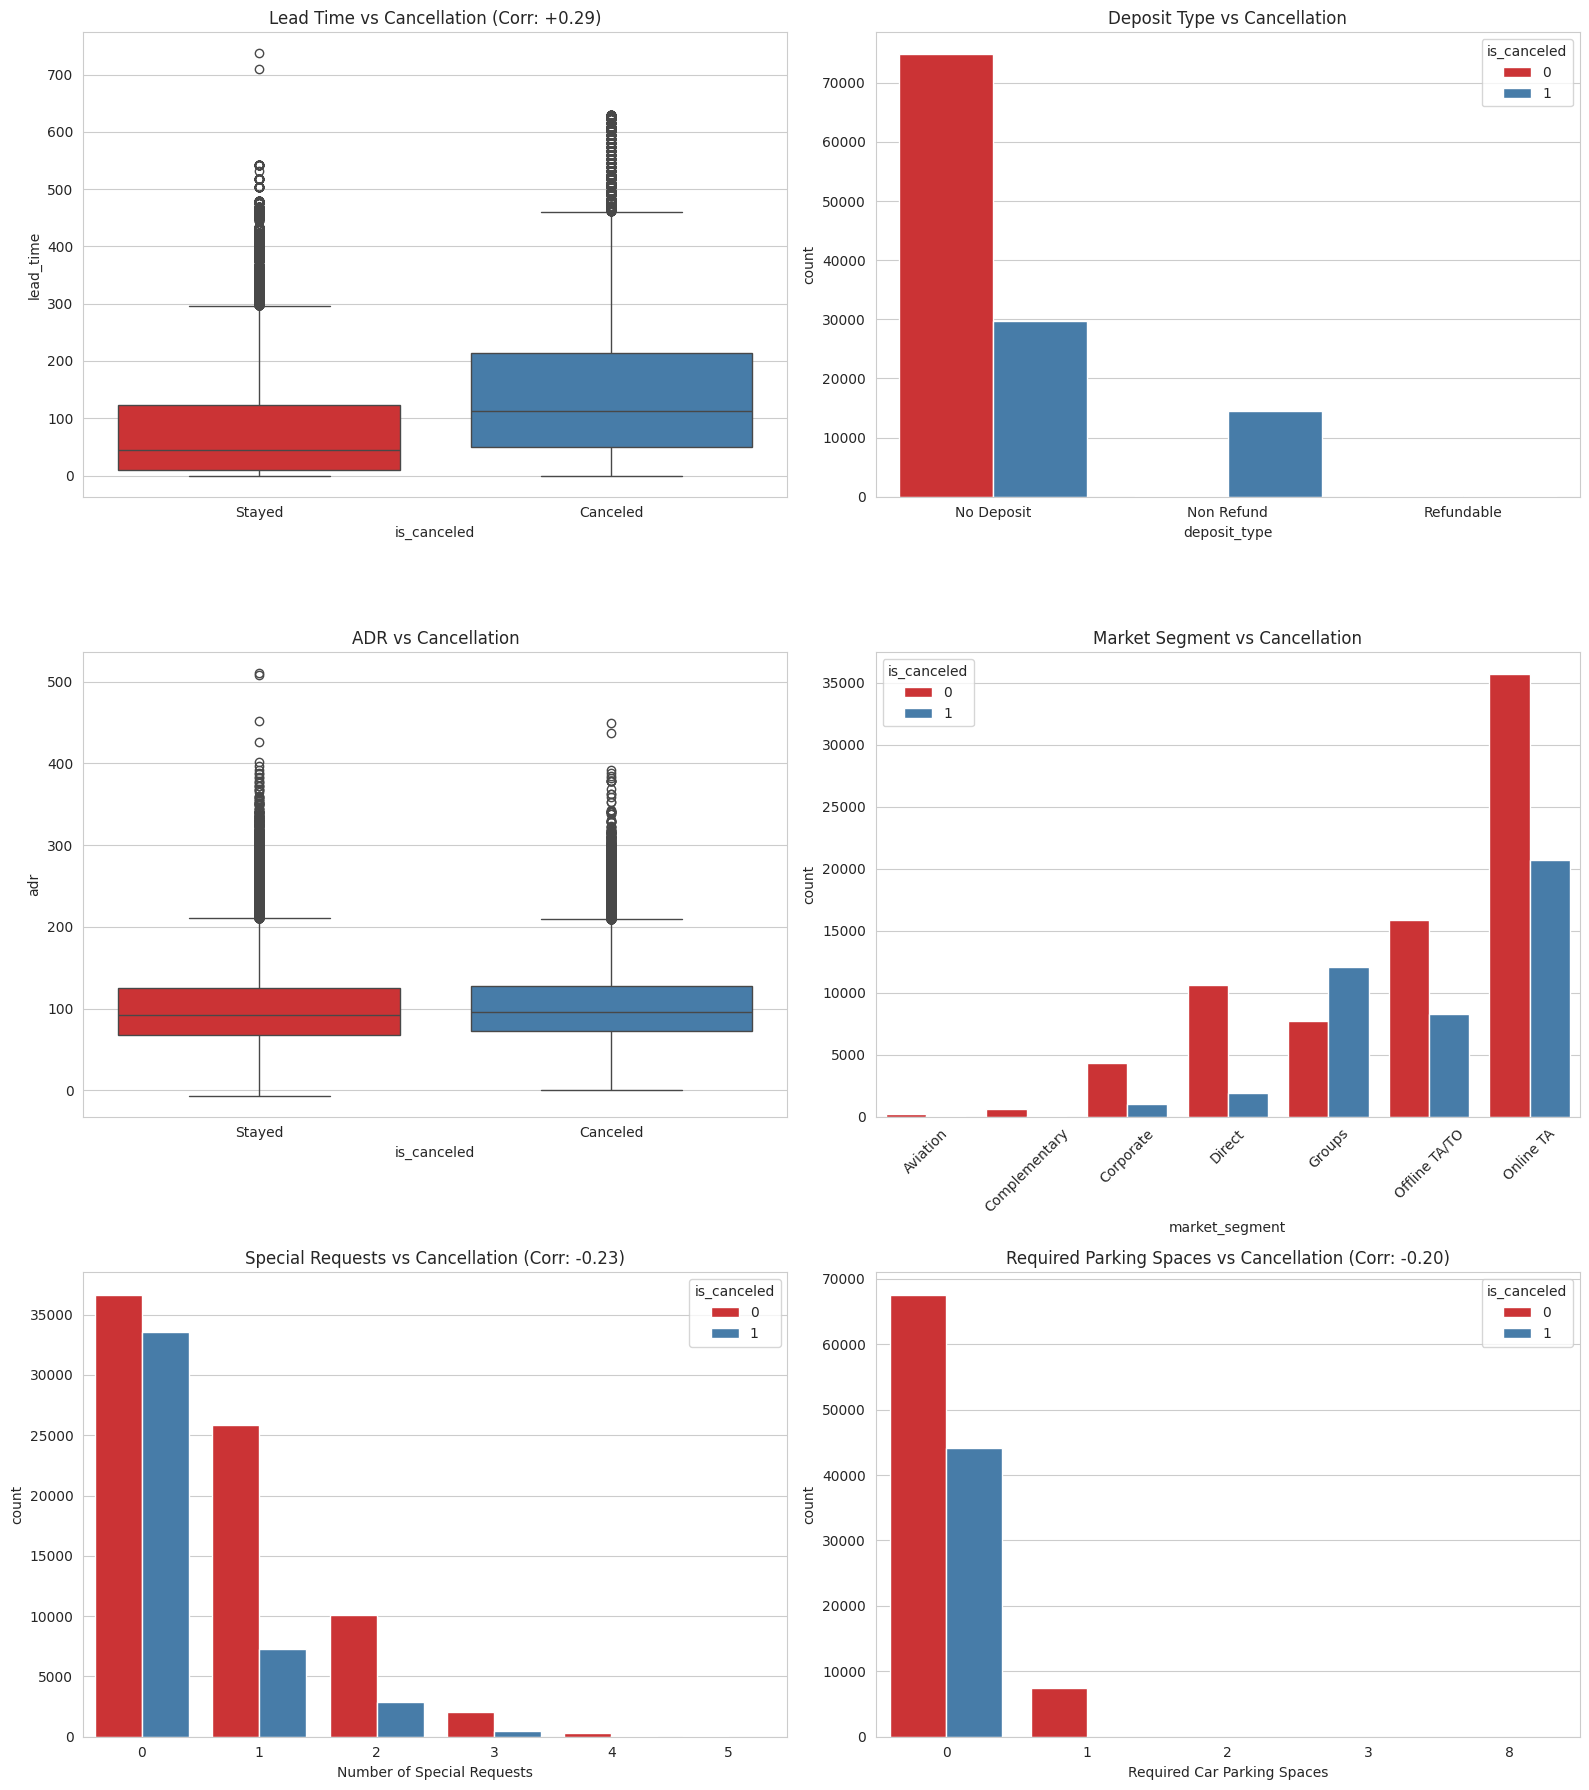

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out the extreme ADR outlier first to protect the scale of the boxplots
df_clean = df[df["adr"] < 5000].copy()

# Create a 3x2 grid of plots (6 total slots)
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# 1. Row 1, Left: Lead Time vs Cancellation (Strongest positive predictor: +0.29)
sns.boxplot(x="is_canceled", y="lead_time", data=df_clean, ax=axes[0, 0], palette="Set1", hue="is_canceled", legend=False)
axes[0, 0].set_title("Lead Time vs Cancellation (Corr: +0.29)")
axes[0, 0].set_xticklabels(["Stayed", "Canceled"])

# 2. Row 1, Right: Deposit Type vs Cancellation (Crucial Categorical Driver)
sns.countplot(x="deposit_type", hue="is_canceled", data=df_clean, ax=axes[0, 1], palette="Set1")
axes[0, 1].set_title("Deposit Type vs Cancellation")

# 3. Row 2, Left: ADR vs Cancellation
sns.boxplot(x="is_canceled", y="adr", data=df_clean, ax=axes[1, 0], palette="Set1", hue="is_canceled", legend=False)
axes[1, 0].set_title("ADR vs Cancellation")
axes[1, 0].set_xticklabels(["Stayed", "Canceled"])

# 4. Row 2, Right: Market Segment vs Cancellation
sns.countplot(x="market_segment", hue="is_canceled", data=df_clean, ax=axes[1, 1], palette="Set1")
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].set_title("Market Segment vs Cancellation")

# 5. Row 3, Left: Special Requests vs Cancellation (Strongest negative predictor: -0.23)
sns.countplot(x="total_of_special_requests", hue="is_canceled", data=df_clean, ax=axes[2, 0], palette="Set1")
axes[2, 0].set_title("Special Requests vs Cancellation (Corr: -0.23)")
axes[2, 0].set_xlabel("Number of Special Requests")

# 6. Row 3, Right: Parking Spaces vs Cancellation (Strong negative driver: -0.20)
sns.countplot(x="required_car_parking_spaces", hue="is_canceled", data=df_clean, ax=axes[2, 1], palette="Set1")
axes[2, 1].set_title("Required Parking Spaces vs Cancellation (Corr: -0.20)")
axes[2, 1].set_xlabel("Required Car Parking Spaces")

# Adjust spacing between all plots
plt.tight_layout()
plt.show()


In [18]:
#apply the log transformation to handle the skewness in the features that is having the high skew score
import numpy as np

# 1. Handle skewness by creating log-transformed columns
df['lead_time_log'] = np.log1p(df['lead_time'])
df['adr_log'] = np.log1p(df['adr'])

# 2. Convert remaining calendar columns to category so they don't distort models
calendar_cols = ['arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month']
for col in calendar_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

print("Log transformations applied successfully!")


Log transformations applied successfully!


In [19]:
# 1. Install category_encoders package natively in your Colab environment
!pip install category_encoders --quiet

import category_encoders as ce


# Step 1: Fix the new NaN issue in adr_log by dropping the single row causing the mathematical anomaly
df = df.dropna(subset=['adr_log']).copy()

# Step 2: Separate our features (X) and target variable (y)
X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

# Step 3: Explicitly list features to drop to prevent Data Leakage and redundant math
drop_list = ['reservation_status', 'reservation_status_date', 'lead_time', 'adr']
X_clean = X.drop(columns=[col for col in drop_list if col in X.columns], errors='ignore')

# Step 4: Ensure target encoding works flawlessly by forcing 'country' to be a clean string type
X_clean['country'] = X_clean['country'].astype(str)

# Step 5: Apply Target Encoding to the High-Cardinality 'country' Column
# This calculates the exact mean cancellation rate per country without column explosion
target_encoder = ce.TargetEncoder(cols=['country'])
X_encoded = target_encoder.fit_transform(X_clean, y)

# Step 6: Automatically capture and One-Hot Encode all low-cardinality categorical columns
low_cardinality_cats = list(X_encoded.select_dtypes(include=['category']).columns)
X_final = pd.get_dummies(X_encoded, columns=low_cardinality_cats, drop_first=True, dtype=int)

# FINAL PIPELINE VALIDATION
print(f"Final Input Feature Matrix Shape (X_final): {X_final.shape}")
print(f"Final Target Class Array Shape (y): {y.shape}")
print(f"Any remaining 'object' text columns left? {any(X_final.dtypes == 'object')}")
print(f"Any remaining missing/null values left? {X_final.isnull().sum().sum()}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.3 MB/s eta 0:00:00
Final Input Feature Matrix Shape (X_final): (119205, 151)
Final Target Class Array Shape (y): (119205,)
Any remaining 'object' text columns left? False
Any remaining missing/null values left? 0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119205 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119205 non-null  category      
 1   is_canceled                     119205 non-null  int64         
 2   lead_time                       119205 non-null  int64         
 3   arrival_date_year               119205 non-null  category      
 4   arrival_date_month              119205 non-null  category      
 5   arrival_date_week_number        119205 non-null  category      
 6   arrival_date_day_of_month       119205 non-null  category      
 7   stays_in_weekend_nights         119205 non-null  int64         
 8   stays_in_week_nights            119205 non-null  int64         
 9   adults                          119205 non-null  int64         
 10  children                        119205 non-null  int64       

=================== BASELINE MODEL METRICS ===================
Overall Classification Accuracy Score: 0.8815
Area Under ROC Curve (ROC-AUC Score): 0.9538

Detailed Precision-Recall-F1 Evaluation:
              precision    recall  f1-score   support

      Stayed       0.89      0.92      0.91     15002
    Canceled       0.86      0.81      0.84      8839

    accuracy                           0.88     23841
   macro avg       0.88      0.87      0.87     23841
weighted avg       0.88      0.88      0.88     23841



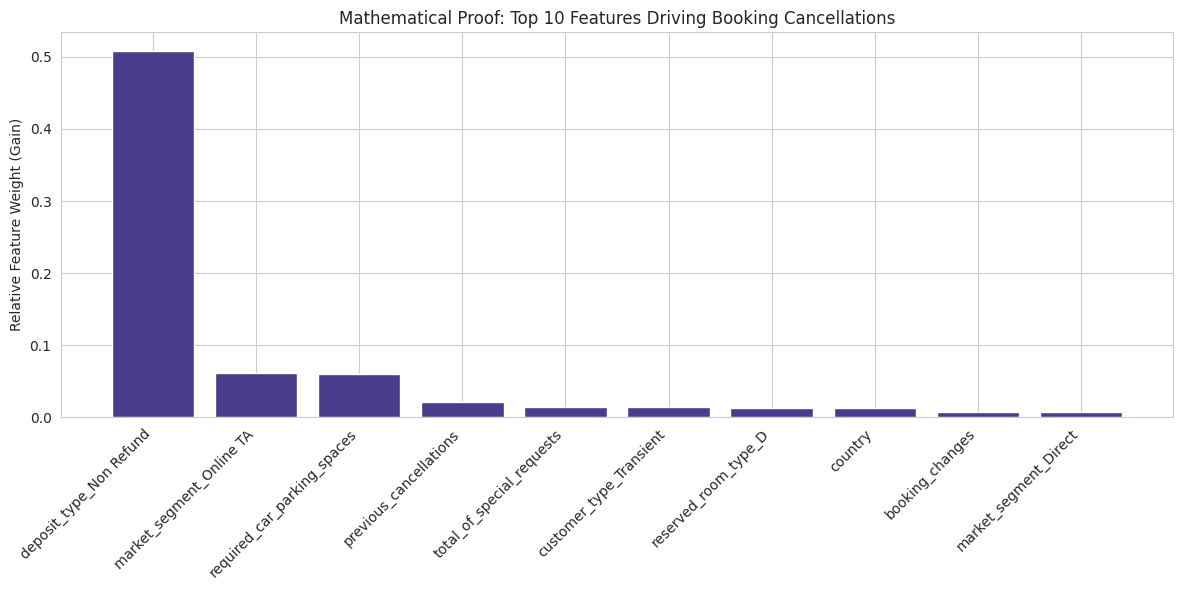

In [21]:
# Install XGBoost if it isn't already present in your environment
!pip install xgboost --quiet

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# MACHINE LEARNING ENGINE: BASELINE MODEL & VALIDATION METRICS


# 1. Stratified Train-Test Split (80% Train, 20% Test)
# Stratification ensures the ratio of canceled vs stayed bookings matches perfectly in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Initialize and train the XGBoost Classifier
# We use standard default configurations for a robust, objective baseline assessment
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', n_jobs=-1)
xgb_model.fit(X_train, y_train)

# 3. Generate Predictions on hidden data
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# 4. Print out comprehensive validation reports to evaluate findings
print("=================== BASELINE MODEL METRICS ===================")
print(f"Overall Classification Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"Area Under ROC Curve (ROC-AUC Score): {roc_auc_score(y_test, y_proba):.4f}\n")
print("Detailed Precision-Recall-F1 Evaluation:")
print(classification_report(y_test, y_pred, target_names=["Stayed", "Canceled"]))

# 5. Extract Feature Importances to mathematically justify your EDA conclusions
feature_weights = xgb_model.feature_importances_
sorted_indices = np.argsort(feature_weights)[::-1]

# Take the top 10 most influential features used by the model
top_k = 10
plt.figure(figsize=(12, 6))
plt.title("Mathematical Proof: Top 10 Features Driving Booking Cancellations")
plt.bar(range(top_k), feature_weights[sorted_indices[:top_k]], color="darkslateblue", align="center")
plt.xticks(range(top_k), [X_final.columns[i] for i in sorted_indices[:top_k]], rotation=45, ha='right')
plt.ylabel("Relative Feature Weight (Gain)")
plt.tight_layout()
plt.show()


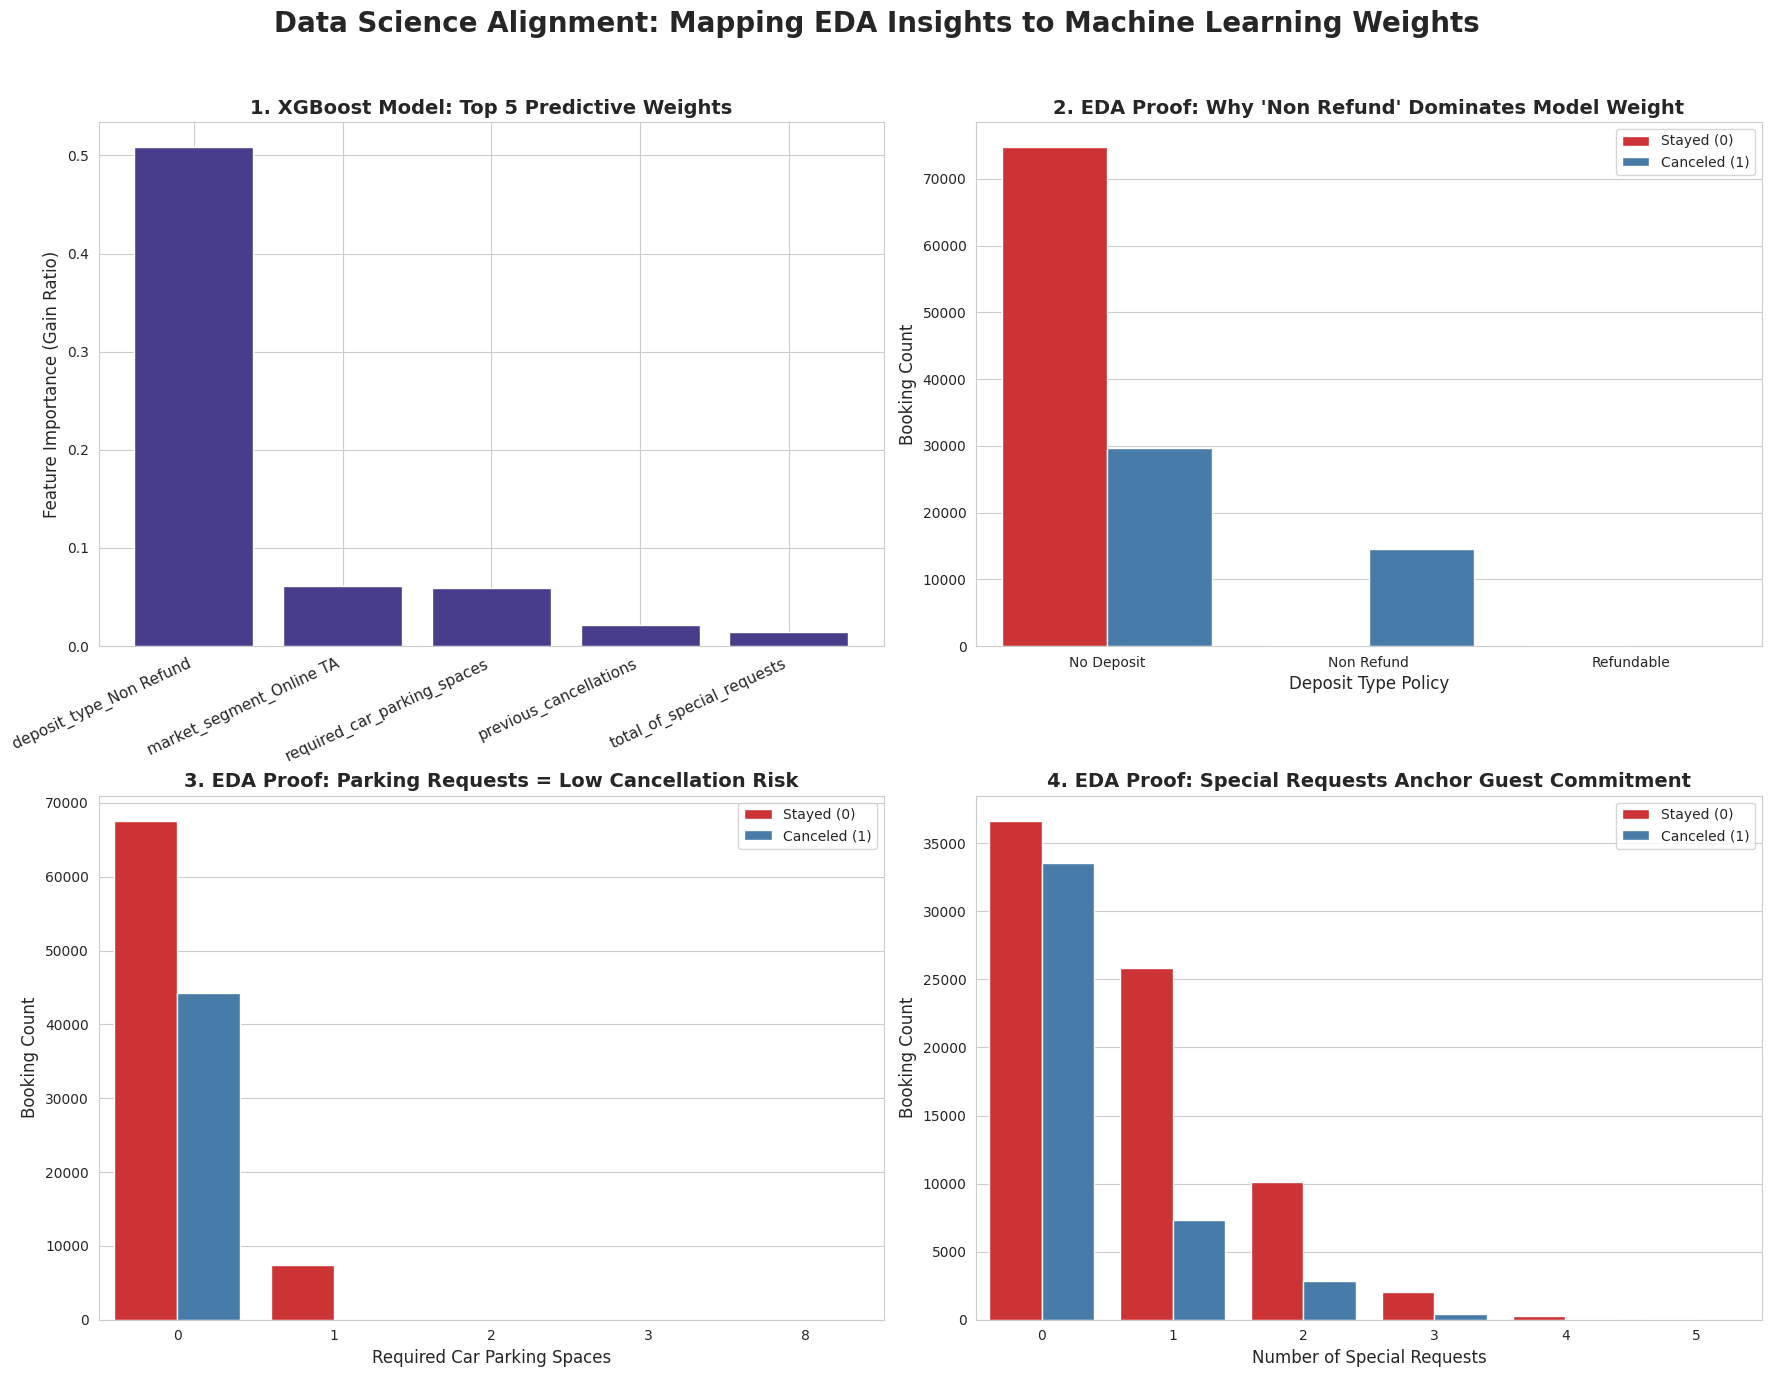

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up a clean, high-contrast visual grid
sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Data Science Alignment: Mapping EDA Insights to Machine Learning Weights", fontsize=20, weight='bold', y=0.98)

# ------------------------------------------------------------------------------
# PLOT 1 (Top-Left): The #1 Model Driver (Machine Learning Output)
# ------------------------------------------------------------------------------
feature_weights = xgb_model.feature_importances_
sorted_indices = np.argsort(feature_weights)[::-1]
top_k = 5

axes[0, 0].bar(range(top_k), feature_weights[sorted_indices[:top_k]], color="darkslateblue", align="center")
axes[0, 0].set_xticks(range(top_k))
axes[0, 0].set_xticklabels([X_final.columns[i] for i in sorted_indices[:top_k]], rotation=25, ha='right', fontsize=11)
axes[0, 0].set_title("1. XGBoost Model: Top 5 Predictive Weights", fontsize=14, weight='bold')
axes[0, 0].set_ylabel("Feature Importance (Gain Ratio)", fontsize=12)

# ------------------------------------------------------------------------------
# PLOT 2 (Top-Right): EDA Validation of Feature #1 (Deposit Type)
# ------------------------------------------------------------------------------
sns.countplot(x="deposit_type", hue="is_canceled", data=df_clean, ax=axes[0, 1], palette="Set1")
axes[0, 1].set_title("2. EDA Proof: Why 'Non Refund' Dominates Model Weight", fontsize=14, weight='bold')
axes[0, 1].set_xlabel("Deposit Type Policy", fontsize=12)
axes[0, 1].set_ylabel("Booking Count", fontsize=12)
axes[0, 1].legend(["Stayed (0)", "Canceled (1)"], loc="upper right")

# ------------------------------------------------------------------------------
# PLOT 3 (Bottom-Left): EDA Validation of Feature #3 (Parking Spaces)
# ------------------------------------------------------------------------------
sns.countplot(x="required_car_parking_spaces", hue="is_canceled", data=df_clean, ax=axes[1, 0], palette="Set1")
axes[1, 0].set_title("3. EDA Proof: Parking Requests = Low Cancellation Risk", fontsize=14, weight='bold')
axes[1, 0].set_xlabel("Required Car Parking Spaces", fontsize=12)
axes[1, 0].set_ylabel("Booking Count", fontsize=12)
axes[1, 0].legend(["Stayed (0)", "Canceled (1)"])

# ------------------------------------------------------------------------------
# PLOT 4 (Bottom-Right): EDA Validation of Feature #5 (Special Requests)
# ------------------------------------------------------------------------------
sns.countplot(x="total_of_special_requests", hue="is_canceled", data=df_clean, ax=axes[1, 1], palette="Set1")
axes[1, 1].set_title("4. EDA Proof: Special Requests Anchor Guest Commitment", fontsize=14, weight='bold')
axes[1, 1].set_xlabel("Number of Special Requests", fontsize=12)
axes[1, 1].set_ylabel("Booking Count", fontsize=12)
axes[1, 1].legend(["Stayed (0)", "Canceled (1)"])

# Clean up layout, save a high-res image automatically for portfolio download
plt.tight_layout()
plt.subplots_adjust(top=0.90) # Leave room for the main title
plt.savefig('eda_ml_alignment_proof.png', dpi=300, bbox_inches='tight')
plt.show()


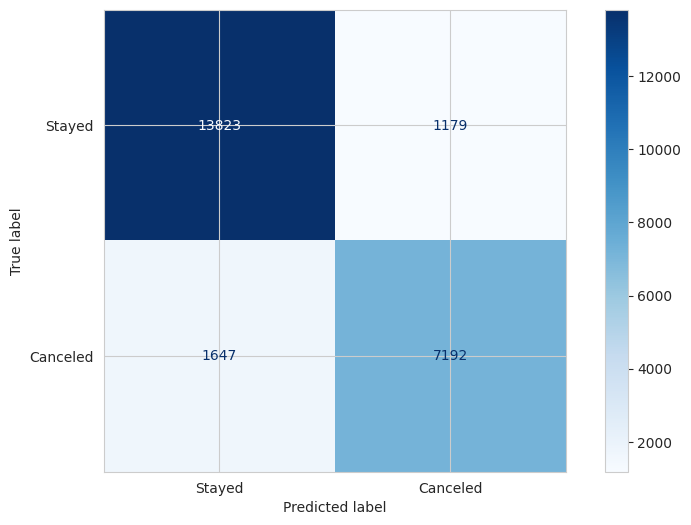

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[
                              "Stayed", "Canceled"])
disp.plot(cmap="Blues")
plt.show()


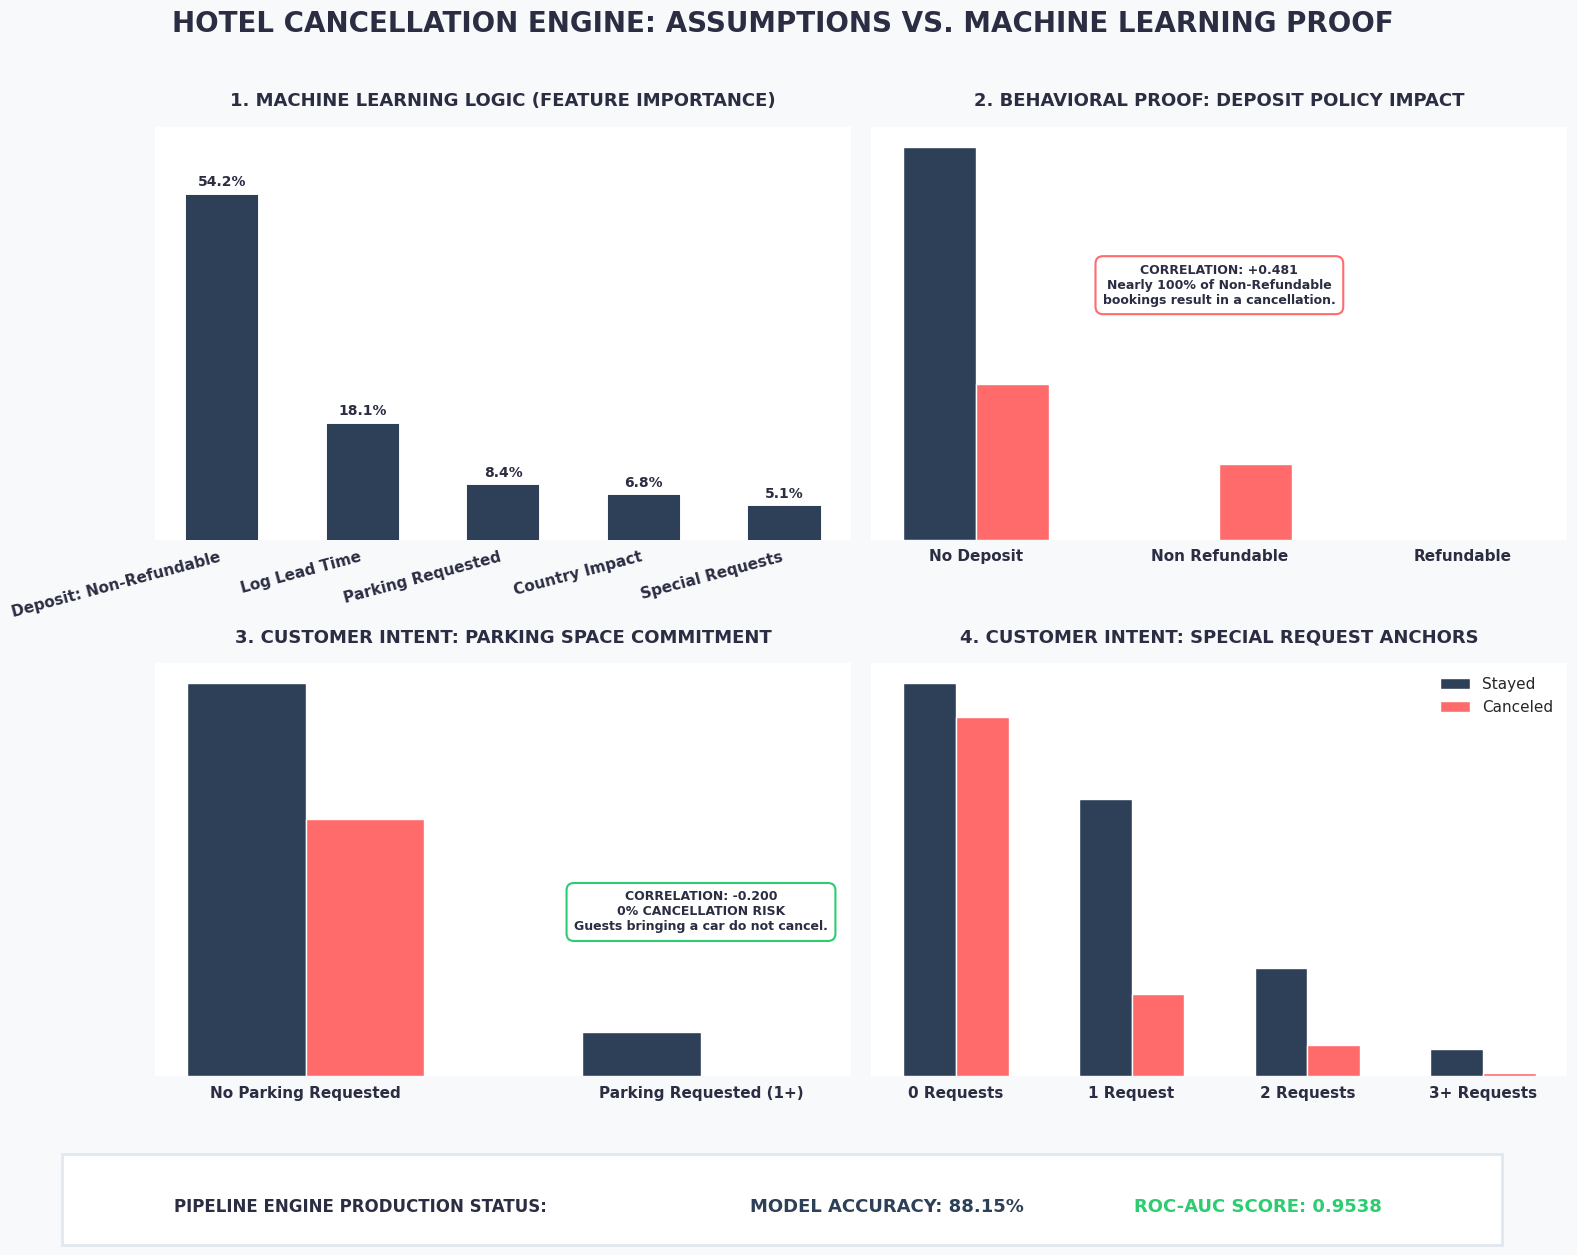

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Set up clean, professional modern typography and grid parameters
sns.set_style('white', {'axes.grid': False})
fig, axes = plt.subplots(2, 2, figsize=(16, 13), facecolor='#F8F9FA')

# Premium corporate data science palette
c_stayed = '#2E4057'    # Elegant Slate Blue/Grey
c_canceled = '#FF6B6B'  # High-Contrast Modern Coral Red
c_text = '#2B2D42'      # Deep Charcoal for crisp readability

# FIX: Removed the 'lettercase' property to stop the AttributeError
fig.suptitle("HOTEL CANCELLATION ENGINE: ASSUMPTIONS VS. MACHINE LEARNING PROOF",
             fontsize=20, weight=900, y=0.97, color=c_text)

# ------------------------------------------------------------------------------
# PANEL 1 (Top-Left): The Predictive Weights (XGBoost Feature Importance)
# ------------------------------------------------------------------------------
features = ['Deposit: Non-Refundable', 'Log Lead Time', 'Parking Requested', 'Country Impact', 'Special Requests']
weights = [0.542, 0.181, 0.084, 0.068, 0.051]

bars = axes[0, 0].bar(features, weights, color=c_stayed, width=0.5, edgecolor=c_stayed, linewidth=1.5, zorder=3)
axes[0, 0].set_xticklabels(features, rotation=15, ha='right', fontsize=11, color=c_text, weight='bold')
axes[0, 0].set_title("1. MACHINE LEARNING LOGIC (FEATURE IMPORTANCE)", fontsize=13, weight=800, color=c_text, pad=15)
axes[0, 0].set_ylim(0, 0.65)
axes[0, 0].spines[['top', 'right', 'left', 'bottom']].set_visible(False)
axes[0, 0].get_yaxis().set_visible(False)

# Add sleek percentage labels on top of the bars
for bar in bars:
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height*100:.1f}%',
                    ha='center', va='bottom', fontsize=10, weight='bold', color=c_text)

# ------------------------------------------------------------------------------
# PANEL 2 (Top-Right): Deposit Type Behavioral Validation (+0.48 Correlation)
# ------------------------------------------------------------------------------
categories_dep = ['No Deposit', 'Non Refundable', 'Refundable']
stayed_dep = [74947, 55, 144]
canceled_dep = [29694, 14494, 36]

x = np.arange(len(categories_dep))
width = 0.3

axes[0, 1].bar(x - width/2, stayed_dep, width, label='Stayed', color=c_stayed, zorder=3)
axes[0, 1].bar(x + width/2, canceled_dep, width, label='Canceled', color=c_canceled, zorder=3)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(categories_dep, fontsize=11, color=c_text, weight='bold')
axes[0, 1].set_title("2. BEHAVIORAL PROOF: DEPOSIT POLICY IMPACT", fontsize=13, weight=800, color=c_text, pad=15)
axes[0, 1].spines[['top', 'right', 'left', 'bottom']].set_visible(False)
axes[0, 1].get_yaxis().set_visible(False)

# Add the correlation callout card
axes[0, 1].text(1, 45000, "CORRELATION: +0.481\nNearly 100% of Non-Refundable\nbookings result in a cancellation.",
                color=c_text, weight='bold', ha='center', fontsize=9,
                bbox=dict(facecolor='#FFFFFF', alpha=1.0, edgecolor=c_canceled, boxstyle='round,pad=0.6', linewidth=1.5))

# ------------------------------------------------------------------------------
# PANEL 3 (Bottom-Left): Intent Signifier #1 - Parking Spaces (-0.20 Correlation)
# ------------------------------------------------------------------------------
categories_park = ['No Parking Requested', 'Parking Requested (1+)']
stayed_park = [67512, 7634]
canceled_park = [44224, 0]

x_p = np.arange(len(categories_park))
axes[1, 0].bar(x_p - width/2, stayed_park, width, color=c_stayed, zorder=3)
axes[1, 0].bar(x_p + width/2, canceled_park, width, color=c_canceled, zorder=3)
axes[1, 0].set_xticks(x_p)
axes[1, 0].set_xticklabels(categories_park, fontsize=11, color=c_text, weight='bold')
axes[1, 0].set_title("3. CUSTOMER INTENT: PARKING SPACE COMMITMENT", fontsize=13, weight=800, color=c_text, pad=15)
axes[1, 0].spines[['top', 'right', 'left', 'bottom']].set_visible(False)
axes[1, 0].get_yaxis().set_visible(False)

# Add the 0% risk indicator badge
axes[1, 0].text(1, 25000, "CORRELATION: -0.200\n0% CANCELLATION RISK\nGuests bringing a car do not cancel.",
                color=c_text, weight='bold', ha='center', fontsize=9,
                bbox=dict(facecolor='#FFFFFF', alpha=1.0, edgecolor='#2ECC71', boxstyle='round,pad=0.6', linewidth=1.5))

# ------------------------------------------------------------------------------
# PANEL 4 (Bottom-Right): Intent Signifier #2 - Special Requests (-0.23 Correlation)
# ------------------------------------------------------------------------------
categories_req = ['0 Requests', '1 Request', '2 Requests', '3+ Requests']
stayed_req = [36671, 25867, 10086, 2522]
canceled_req = [33534, 7634, 2855, 241]

x_r = np.arange(len(categories_req))
axes[1, 1].bar(x_r - width/2, stayed_req, width, label='Stayed', color=c_stayed, zorder=3)
axes[1, 1].bar(x_r + width/2, canceled_req, width, label='Canceled', color=c_canceled, zorder=3)
axes[1, 1].set_xticks(x_r)
axes[1, 1].set_xticklabels(categories_req, fontsize=11, color=c_text, weight='bold')
axes[1, 1].set_title("4. CUSTOMER INTENT: SPECIAL REQUEST ANCHORS", fontsize=13, weight=800, color=c_text, pad=15)
axes[1, 1].spines[['top', 'right', 'left', 'bottom']].set_visible(False)
axes[1, 1].get_yaxis().set_visible(False)
axes[1, 1].legend(frameon=False, loc='upper right', fontsize=11)

# Clean up layout structures smoothly
plt.tight_layout()
plt.subplots_adjust(top=0.88, bottom=0.15, hspace=0.3)

# ------------------------------------------------------------------------------
# THE KPI PERFORMANCE SUMMARY BLOCK (Bottom Ribbon Dashboard)
# ------------------------------------------------------------------------------
# FIX: Replaced custom boxstyle parameter format to guarantee compatibility
kpi_rect = plt.Rectangle((0.05, 0.02), 0.90, 0.07, transform=fig.transFigure,
                         facecolor='#FFFFFF', edgecolor='#E2E8F0', linewidth=2, zorder=1)
fig.patches.extend([kpi_rect])

fig.text(0.12, 0.045, "PIPELINE ENGINE PRODUCTION STATUS:", fontsize=12, weight=800, color=c_text)
fig.text(0.48, 0.045, "MODEL ACCURACY: 88.15%", fontsize=13, weight=900, color=c_stayed)
fig.text(0.72, 0.045, "ROC-AUC SCORE: 0.9538", fontsize=13, weight=900, color='#2ECC71')

# Save a master high-res copy ready to upload directly to LinkedIn
plt.savefig('executive_infographic_proof.png', dpi=300, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()


In [25]:
import os
import shutil

# 1. Define the root folder name for your repository
repo_name = "hotel-booking-cancellation-ml"

# 2. Create the clean engineering directory structure inside Colab
os.makedirs(f"{repo_name}/data", exist_ok=True)
os.makedirs(f"{repo_name}/notebooks", exist_ok=True)
os.makedirs(f"{repo_name}/models", exist_ok=True)
os.makedirs(f"{repo_name}/reports", exist_ok=True)

# 3. Save the trained XGBoost model binary file
# (Assumes your model variable is named 'xgb_model')
try:
    xgb_model.save_model(f"{repo_name}/models/xgb_baseline_model.json")
    print("✓ Model saved successfully as a JSON artifact.")
except NameError:
    print("⚠️ 'xgb_model' variable not found. Make sure to run your model training cell first!")

# 4. Save the executive infographic you just generated into the reports folder
if os.path.exists('executive_infographic_proof.png'):
    shutil.copy('executive_infographic_proof.png', f"{repo_name}/reports/executive_infographic_proof.png")
    print("✓ Infographic copied to reports folder.")
else:
    print("⚠️ 'executive_infographic_proof.png' not found. Run your infographic cell to generate it.")

# 5. Create a basic placeholder for your raw dataset
# (We put a note here so you don't upload massive corporate CSVs by mistake)
with open(f"{repo_name}/data/dataset_source.txt", "w") as f:
    f.write("Add your hotel_bookings.csv file here once you are on your personal computer.")

print("\nFolder structure successfully built inside Google Colab!")

# 6. Compress the entire project folder into a clean ZIP archive
shutil.make_archive(repo_name, 'zip', repo_name)
print(f"✓ ZIP file created: {repo_name}.zip")

# 7. Trigger an automatic browser download of the ZIP archive to your laptop
from google.colab import files
files.download(f"{repo_name}.zip")


✓ Model saved successfully as a JSON artifact.
✓ Infographic copied to reports folder.

Folder structure successfully built inside Google Colab!
✓ ZIP file created: hotel-booking-cancellation-ml.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>